# ITA Challenge Sprint | Desafio 3 - Caderno Inteligente
## Semana 1: diagnóstico do problema | Notebook de evidências rastreáveis

Cada número usado na entrega é registrado aqui com:

| Campo | O que é |
|---|---|
| **Origem** | aba e colunas exatas da base |
| **Expressão** | o filtro ou cálculo, em código |
| **Natureza** | `apurado` = calculado da base, `declarado` = informado pela empresa e não recalculável |
| **Suporte** | as linhas que sustentam o número, exibíveis linha a linha |

Nada é digitado a mão. Ao final, `trilha_evidencias_semana1.csv` exporta a auditoria completa e
`suporte_<ID>.csv` exporta as linhas de cada evidência.

> Todos os dados da base são fictícios e foram criados para o desafio.

## 0. Carga da base

In [ ]:
import os
ARQUIVO = "Base de Dados - Caderno Inteligente.xlsm"

if not os.path.exists(ARQUIVO):
    try:
        from google.colab import files
        ARQUIVO = list(files.upload().keys())[0]
    except ImportError:
        raise FileNotFoundError("Coloque o .xlsm ao lado do notebook ou ajuste a variavel ARQUIVO.")
print("Arquivo:", ARQUIVO)

Arquivo: Base de Dados - Caderno Inteligente.xlsm


In [ ]:
import pandas as pd, numpy as np, hashlib
import matplotlib.pyplot as plt

pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (10, 4.5); plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = .25

# O cabecalho real das abas esta na 3a linha do Excel: as duas primeiras sao titulo e espacador.
def carregar(aba, pular=2):
    return pd.read_excel(ARQUIVO, sheet_name=aba, skiprows=pular, engine="openpyxl")

ABAS = pd.ExcelFile(ARQUIVO, engine="openpyxl").sheet_names

produtos    = carregar("Produtos")
estoque     = carregar("Estoque_Atual")
carteira    = carregar("Carteira_Pedidos")
ordens      = carregar("Ordens_Producao")
capacidade  = carregar("Capacidade_Semanal")
sell_in     = carregar("Sell_In")
sell_out    = carregar("Sell_Out")
vendas      = carregar("Vendas_24m")
forecast    = carregar("Forecast_Comercial")
parceiros   = carregar("Parceiros_Canais")
precos      = carregar("Precos_Produtos")
eventos     = carregar("Calendario_Eventos")
indicadores = carregar("Indicadores_Atuais")

carteira["Data prometida"]   = pd.to_datetime(carteira["Data prometida"], dayfirst=True)
ordens["Conclusão prevista"] = pd.to_datetime(ordens["Conclusão prevista"], dayfirst=True)
ordens["Início previsto"]    = pd.to_datetime(ordens["Início previsto"], dayfirst=True)
sell_in["Mês"]  = pd.to_datetime(sell_in["Mês"])
sell_out["Mês"] = pd.to_datetime(sell_out["Mês"])
vendas["Mês"]   = pd.to_datetime(vendas["Mês"])

# Impressao digital do arquivo: garante que todos analisaram a mesma versao da base
with open(ARQUIVO, "rb") as f:
    print("SHA-256 da base:", hashlib.sha256(f.read()).hexdigest()[:16])
print(f"{len(ABAS)} abas carregadas | referencia da base: setembro de 2026")

SHA-256 da base: 03fa0ed400aa3f8e
18 abas carregadas | referencia da base: setembro de 2026


## 1. O registro de evidências

`registrar()` guarda cada número junto com a sua procedência. `suporte()` mostra as linhas da base
que produziram aquele número, para que qualquer afirmação da entrega possa ser aberta na frente da
banca.

In [ ]:
EVIDENCIAS = {}

def registrar(id, bloco, criterio, origem, expressao, valor, natureza="apurado", suporte=None):
    """Registra uma evidencia com a sua procedencia completa."""
    EVIDENCIAS[id] = dict(id=id, bloco=bloco, criterio=criterio, origem=origem,
                          expressao=expressao, valor=valor, natureza=natureza,
                          linhas_suporte=0 if suporte is None else len(suporte), _suporte=suporte)
    marca = "[apurado]" if natureza == "apurado" else "[declarado]"
    print(f"{id:8s} {marca:12s} {criterio}")
    print(f"{'':8s} valor ....... {valor}")
    print(f"{'':8s} origem ...... {origem}")
    print(f"{'':8s} expressao ... {expressao}")
    if suporte is not None:
        print(f"{'':8s} suporte ..... {len(suporte)} linhas (use suporte('{id}'))")
    print()

def suporte(id, n=None):
    """Devolve as linhas da base que sustentam a evidencia."""
    s = EVIDENCIAS[id]["_suporte"]
    if s is None:
        print(f"{id}: numero declarado pela empresa, sem linha de base para abrir.")
        return None
    return s if n is None else s.head(n)

def trilha():
    """Tabela de auditoria de todas as evidencias registradas."""
    return pd.DataFrame([{k: v for k, v in e.items() if not k.startswith("_")}
                         for e in EVIDENCIAS.values()])
print("Registro pronto.")

Registro pronto.


## 2. Ruptura

Três critérios aninhados sobre a mesma aba `Produtos`. A cobertura em dias já vem calculada na
base como estoque atual dividido pela venda média diária, e é reconferida abaixo antes de ser usada.

In [ ]:
# Conferencia do campo Cobertura (dias) contra o seu proprio calculo
chk = produtos.assign(recalc=(produtos["Estoque atual"] / produtos["Venda média/dia"]).round(0))
divergentes = chk[(chk["recalc"] - chk["Cobertura (dias)"]).abs() > 1]
print(f"Cobertura (dias) confere com Estoque atual / Venda media/dia em "
      f"{len(chk) - len(divergentes)} de {len(chk)} SKUs.")
if len(divergentes):
    print(divergentes[["SKU", "Estoque atual", "Venda média/dia", "Cobertura (dias)", "recalc"]].to_string(index=False))

Cobertura (dias) confere com Estoque atual / Venda media/dia em 50 de 50 SKUs.


In [ ]:
base_sku = produtos.copy()

f_lt = base_sku["Cobertura (dias)"] < base_sku["Lead time (dias)"]
registrar("RUP-01", "Ruptura",
          "Cobertura de estoque inferior ao lead time de reposicao",
          "Produtos: Cobertura (dias), Lead time (dias)",
          'produtos["Cobertura (dias)"] < produtos["Lead time (dias)"]',
          f"{f_lt.sum()} de {len(base_sku)} SKUs",
          suporte=base_sku.loc[f_lt, ["SKU", "Produto", "Família", "Curva ABC",
                                      "Estoque atual", "Cobertura (dias)", "Lead time (dias)"]]
                      .sort_values("Cobertura (dias)"))

f_es = base_sku["Cobertura (dias)"] < base_sku["Estoque segurança (dias)"]
registrar("RUP-02", "Ruptura",
          "Cobertura inferior ao estoque de seguranca definido",
          "Produtos: Cobertura (dias), Estoque segurança (dias)",
          'produtos["Cobertura (dias)"] < produtos["Estoque segurança (dias)"]',
          f"{f_es.sum()} de {len(base_sku)} SKUs",
          suporte=base_sku.loc[f_es, ["SKU", "Produto", "Família", "Cobertura (dias)",
                                      "Estoque segurança (dias)", "Lead time (dias)"]]
                      .sort_values("Cobertura (dias)"))

base_sku["risco_lead_time"] = f_lt
base_sku["abaixo_seguranca"] = f_es

RUP-01   [apurado]    Cobertura de estoque inferior ao lead time de reposicao
         valor ....... 15 de 50 SKUs
         origem ...... Produtos: Cobertura (dias), Lead time (dias)
         expressao ... produtos["Cobertura (dias)"] < produtos["Lead time (dias)"]
         suporte ..... 15 linhas (use suporte('RUP-01'))

RUP-02   [apurado]    Cobertura inferior ao estoque de seguranca definido
         valor ....... 13 de 50 SKUs
         origem ...... Produtos: Cobertura (dias), Estoque segurança (dias)
         expressao ... produtos["Cobertura (dias)"] < produtos["Estoque segurança (dias)"]
         suporte ..... 13 linhas (use suporte('RUP-02'))



In [ ]:
# Posicao projetada: cruza tres abas
cart_sku = carteira.groupby("SKU")["Quantidade"].sum().rename("carteira")
ord_sku  = ordens.groupby("SKU")["Quantidade"].sum().rename("ordens")

base_sku = (base_sku.merge(cart_sku, on="SKU", how="left")
                    .merge(ord_sku,  on="SKU", how="left")
                    .fillna({"carteira": 0, "ordens": 0}))
base_sku["posicao_projetada"] = base_sku["Estoque atual"] + base_sku["ordens"] - base_sku["carteira"]
f_neg = base_sku["posicao_projetada"] < 0

registrar("RUP-03", "Ruptura",
          "Posicao projetada negativa: estoque atual mais ordens abertas nao cobre a carteira",
          "Produtos: Estoque atual | Ordens_Producao: Quantidade | Carteira_Pedidos: Quantidade",
          'Estoque atual + soma(Ordens.Quantidade) - soma(Carteira.Quantidade) < 0',
          f"{f_neg.sum()} de {len(base_sku)} SKUs",
          suporte=base_sku.loc[f_neg, ["SKU", "Produto", "Família", "Curva ABC", "Estoque atual",
                                       "ordens", "carteira", "posicao_projetada"]]
                      .sort_values("posicao_projetada"))
base_sku["posicao_negativa"] = f_neg

RUP-03   [apurado]    Posicao projetada negativa: estoque atual mais ordens abertas nao cobre a carteira
         valor ....... 5 de 50 SKUs
         origem ...... Produtos: Estoque atual | Ordens_Producao: Quantidade | Carteira_Pedidos: Quantidade
         expressao ... Estoque atual + soma(Ordens.Quantidade) - soma(Carteira.Quantidade) < 0
         suporte ..... 5 linhas (use suporte('RUP-03'))



In [ ]:
# Abrindo a evidencia mais grave, linha a linha
suporte("RUP-03")

,SKU,Produto,Família,Curva ABC,Estoque atual,ordens,carteira,posicao_projetada
3,CI-0004,Planner Semanal,Planner,A,303,0.0,866.0,-563.0
35,CI-0036,Caderno A5 Verde,Clássico,B,742,0.0,1219.0,-477.0
17,CI-0018,Refil Checklist,Refis,A,50,500.0,921.0,-371.0
19,CI-0020,Capa Colorida A5,Acessórios,A,354,0.0,680.0,-326.0
15,CI-0016,Caderno Escolar Rosa,Escolar,A,150,0.0,255.0,-105.0


In [ ]:
# E os pedidos individuais por tras de um desses SKUs
sku_exemplo = base_sku.loc[base_sku.posicao_negativa].sort_values("posicao_projetada").iloc[0]["SKU"]
print(f"Pedidos em carteira de {sku_exemplo}:")
print(carteira[carteira.SKU == sku_exemplo].to_string(index=False))
print()
print(f"Ordens de producao de {sku_exemplo}:")
op_sku = ordens[ordens.SKU == sku_exemplo]
print("  nenhuma ordem aberta" if op_sku.empty else op_sku.to_string(index=False))

In [ ]:
fig, ax = plt.subplots()
rot = ["RUP-01\ncobertura < lead time", "RUP-02\nabaixo do estoque seg.", "RUP-03\nposicao negativa"]
val = [f_lt.sum(), f_es.sum(), f_neg.sum()]
b = ax.bar(rot, val, color=["#8FAADC", "#4472C4", "#1F3864"])
ax.bar_label(b, padding=3, fontsize=11); ax.set_ylabel("SKUs")
ax.set_title(f"Funil de risco de ruptura ({len(base_sku)} SKUs)"); ax.set_ylim(0, max(val)*1.25)
plt.tight_layout(); plt.show()

## 3. Excesso e capital imobilizado

O valor usa o preço de tabela da aba `Precos_Produtos`, porque a base não traz custo nem margem.
O número é ordem de grandeza de capital a preço de venda, e isso fica registrado na própria
evidência.

In [ ]:
base_sku = base_sku.merge(precos[["SKU", "Preço unitário (R$)"]], on="SKU", how="left")
base_sku["valor_estoque"] = base_sku["Estoque atual"] * base_sku["Preço unitário (R$)"]
f_exc = base_sku["Cobertura (dias)"] > 90

registrar("EXC-01", "Excesso",
          "Cobertura de estoque superior a 90 dias",
          "Produtos: Cobertura (dias)",
          'produtos["Cobertura (dias)"] > 90',
          f"{f_exc.sum()} de {len(base_sku)} SKUs, cobertura maxima de {base_sku['Cobertura (dias)'].max():.0f} dias",
          suporte=base_sku.loc[f_exc, ["SKU", "Produto", "Família", "Status", "Estoque atual",
                                       "Cobertura (dias)", "valor_estoque"]]
                      .sort_values("valor_estoque", ascending=False))

registrar("EXC-02", "Excesso",
          "Capital imobilizado nos SKUs acima de 90 dias, a preco de tabela",
          "Produtos: Estoque atual | Precos_Produtos: Preço unitário (R$)",
          'soma(Estoque atual * Preço unitário) sobre os SKUs de EXC-01',
          f"R$ {base_sku.loc[f_exc, 'valor_estoque'].sum():,.0f}".replace(",", "."),
          suporte=base_sku.loc[f_exc, ["SKU", "Estoque atual", "Preço unitário (R$)", "valor_estoque"]]
                      .sort_values("valor_estoque", ascending=False))

f_desc = base_sku["Status"].str.contains("Descontinu", case=False, na=False)
registrar("EXC-03", "Excesso",
          "SKUs em descontinuacao, com risco de obsolescencia somado ao excesso",
          "Produtos: Status",
          'produtos["Status"].str.contains("Descontinu")',
          f"{f_desc.sum()} de {len(base_sku)} SKUs",
          suporte=base_sku.loc[f_desc, ["SKU", "Produto", "Status", "Estoque atual",
                                        "Cobertura (dias)", "valor_estoque"]])

base_sku["excesso_90d"] = f_exc
base_sku["descontinuado"] = f_desc
print(f"Contexto: o estoque total da base vale R$ {base_sku['valor_estoque'].sum():,.0f}".replace(",", "."),
      f"| o excesso representa {base_sku.loc[f_exc,'valor_estoque'].sum()/base_sku['valor_estoque'].sum():.0%} desse capital.")

EXC-01   [apurado]    Cobertura de estoque superior a 90 dias
         valor ....... 6 de 50 SKUs, cobertura maxima de 110 dias
         origem ...... Produtos: Cobertura (dias)
         expressao ... produtos["Cobertura (dias)"] > 90
         suporte ..... 6 linhas (use suporte('EXC-01'))

EXC-02   [apurado]    Capital imobilizado nos SKUs acima de 90 dias, a preco de tabela
         valor ....... R$ 760.183
         origem ...... Produtos: Estoque atual | Precos_Produtos: Preço unitário (R$)
         expressao ... soma(Estoque atual * Preço unitário) sobre os SKUs de EXC-01
         suporte ..... 6 linhas (use suporte('EXC-02'))

EXC-03   [apurado]    SKUs em descontinuacao, com risco de obsolescencia somado ao excesso
         valor ....... 2 de 50 SKUs
         origem ...... Produtos: Status
         expressao ... produtos["Status"].str.contains("Descontinu")
         suporte ..... 2 linhas (use suporte('EXC-03'))

Contexto: o estoque total da base vale R$ 2.171.142 | o excesso rep

In [ ]:
suporte("EXC-01")

,SKU,Produto,Família,Status,Estoque atual,Cobertura (dias),valor_estoque
39,CI-0040,Caderno Executivo,Executivo,Ativo,2233,110,290066.7
21,CI-0022,Caderno Executivo Preto,Executivo,Ativo,1672,110,192112.8
20,CI-0021,Caderno A5 Preto,Clássico,Ativo,1485,110,118651.5
43,CI-0044,Disco M Azul,Acessórios,Ativo,2981,110,89131.9
37,CI-0038,Refil Planner,Refis,Ativo,1858,110,55554.2
31,CI-0032,Disco M Rosa,Acessórios,Ativo,737,110,14666.3


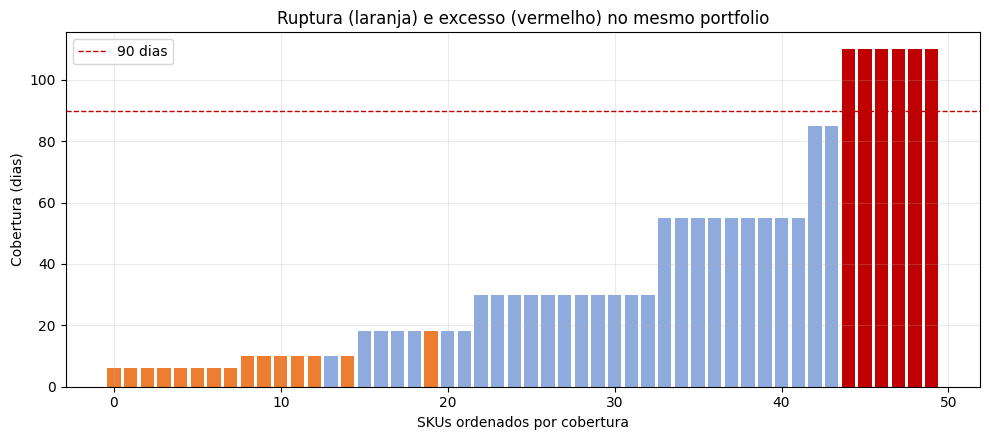

In [ ]:
ordenado = base_sku.sort_values("Cobertura (dias)")
cores = np.where(ordenado["Cobertura (dias)"] > 90, "#C00000",
         np.where(ordenado["Cobertura (dias)"] < ordenado["Lead time (dias)"], "#ED7D31", "#8FAADC"))
fig, ax = plt.subplots()
ax.bar(range(len(ordenado)), ordenado["Cobertura (dias)"], color=cores)
ax.axhline(90, color="#C00000", ls="--", lw=1, label="90 dias")
ax.set_xlabel("SKUs ordenados por cobertura"); ax.set_ylabel("Cobertura (dias)")
ax.set_title("Ruptura (laranja) e excesso (vermelho) no mesmo portfolio"); ax.legend()
plt.tight_layout(); plt.show()

## 4. Carteira contra produção

A evidência mais forte da base. Duas falhas verificáveis sem depender de nenhum dado de parceiro:
compromisso sem ordem de produção, e ordem que só fica pronta depois da data prometida ao cliente.

In [ ]:
skus_cart = set(carteira["SKU"]); skus_op = set(ordens["SKU"])
sem_op = sorted(skus_cart - skus_op)

registrar("CAR-01", "Carteira",
          "SKUs com pedido em carteira e nenhuma ordem de producao aberta",
          "Carteira_Pedidos: SKU | Ordens_Producao: SKU",
          'set(Carteira.SKU) - set(Ordens.SKU)',
          f"{len(sem_op)} de {len(skus_cart)} SKUs com carteira",
          suporte=(carteira[carteira.SKU.isin(sem_op)]
                   .sort_values(["SKU", "Data prometida"])
                   [["Pedido", "SKU", "Cliente/Canal", "Quantidade", "Data prometida", "Status"]]))

primeira_op = ordens.groupby("SKU")["Conclusão prevista"].min().rename("primeira_conclusao")
prazo = carteira.merge(primeira_op, on="SKU", how="left")
prazo["dias_atraso"] = (prazo["primeira_conclusao"] - prazo["Data prometida"]).dt.days
atrasados = prazo[prazo["dias_atraso"] > 0]

registrar("CAR-02", "Carteira",
          "SKUs cuja primeira ordem de producao conclui depois da data prometida ao cliente",
          "Carteira_Pedidos: SKU, Data prometida | Ordens_Producao: SKU, Conclusão prevista",
          'min(Ordens.Conclusão prevista) por SKU > Carteira.Data prometida',
          f"{atrasados['SKU'].nunique()} SKUs, {len(atrasados)} pedidos, "
          f"{atrasados['Quantidade'].sum():,.0f} unidades, atraso mediano de {atrasados['dias_atraso'].median():.0f} dias".replace(",", "."),
          suporte=atrasados.sort_values("dias_atraso", ascending=False)
                  [["Pedido", "SKU", "Cliente/Canal", "Quantidade", "Data prometida",
                    "primeira_conclusao", "dias_atraso"]])

em_risco = sorted(set(atrasados["SKU"]) | set(sem_op))
registrar("CAR-03", "Carteira",
          "SKUs com carteira sem lastro produtivo no prazo: uniao de CAR-01 e CAR-02",
          "Carteira_Pedidos | Ordens_Producao",
          'CAR-01 uniao CAR-02',
          f"{len(em_risco)} de {len(skus_cart)} SKUs com carteira",
          suporte=pd.DataFrame({"SKU": em_risco,
                                "motivo": ["sem ordem de producao" if s in sem_op else "ordem apos a promessa"
                                           for s in em_risco]}))

registrar("CAR-04", "Carteira",
          "Volume em carteira confirmada contra volume em ordens de producao abertas",
          "Carteira_Pedidos: Quantidade | Ordens_Producao: Quantidade",
          'soma(Carteira.Quantidade) e soma(Ordens.Quantidade)',
          f"{carteira['Quantidade'].sum():,.0f} un em carteira contra {ordens['Quantidade'].sum():,.0f} un em ordens".replace(",", "."),
          suporte=None)

CAR-01   [apurado]    SKUs com pedido em carteira e nenhuma ordem de producao aberta
         valor ....... 12 de 40 SKUs com carteira
         origem ...... Carteira_Pedidos: SKU | Ordens_Producao: SKU
         expressao ... set(Carteira.SKU) - set(Ordens.SKU)
         suporte ..... 15 linhas (use suporte('CAR-01'))

CAR-02   [apurado]    SKUs cuja primeira ordem de producao conclui depois da data prometida ao cliente
         valor ....... 20 SKUs. 26 pedidos. 10.517 unidades. atraso mediano de 10 dias
         origem ...... Carteira_Pedidos: SKU, Data prometida | Ordens_Producao: SKU, Conclusão prevista
         expressao ... min(Ordens.Conclusão prevista) por SKU > Carteira.Data prometida
         suporte ..... 26 linhas (use suporte('CAR-02'))

CAR-03   [apurado]    SKUs com carteira sem lastro produtivo no prazo: uniao de CAR-01 e CAR-02
         valor ....... 32 de 40 SKUs com carteira
         origem ...... Carteira_Pedidos | Ordens_Producao
         expressao ... CAR-01 uniao 

In [ ]:
suporte("CAR-02", 12)

,Pedido,SKU,Cliente/Canal,Quantidade,Data prometida,primeira_conclusao,dias_atraso
16,PED-017-1,CI-0017,KA-05,352,2026-09-16,2026-10-12,26.0
41,PED-041-1,CI-0041,KA-05,512,2026-09-13,2026-10-08,25.0
42,PED-041-2,CI-0041,KA-02,534,2026-09-14,2026-10-08,24.0
28,PED-027-2,CI-0027,KA-01,487,2026-09-13,2026-10-02,19.0
8,PED-011-1,CI-0011,KA-01,620,2026-09-14,2026-10-02,18.0
19,PED-019-1,CI-0019,KA-04,611,2026-09-16,2026-10-02,16.0
27,PED-027-1,CI-0027,KA-05,497,2026-09-16,2026-10-02,16.0
25,PED-025-1,CI-0025,Marketplace,157,2026-09-16,2026-10-01,15.0
44,PED-043-1,CI-0043,E-commerce,214,2026-09-15,2026-09-27,12.0
0,PED-002-1,CI-0002,KA-03,331,2026-09-20,2026-10-01,11.0


## 5. Capacidade

In [ ]:
resumo_cap = (capacidade.groupby("Família")
              .agg(semanas=("Ocupação", "size"),
                   ocupacao_media=("Ocupação", "mean"),
                   ocupacao_max=("Ocupação", "max"),
                   semanas_acima_90=("Ocupação", lambda s: (s > .90).sum()),
                   disponivel_media=("Capacidade disponível", "mean"))
              .sort_values("ocupacao_media", ascending=False))
print(resumo_cap.assign(ocupacao_media=lambda d: (d.ocupacao_media*100).round(1),
                        ocupacao_max=lambda d: (d.ocupacao_max*100).round(1)).to_string())

esc = capacidade[capacidade["Família"] == "Escolar"].sort_values("Semana inicial")
registrar("CAP-01", "Capacidade",
          "Ocupacao media da linha Escolar no horizonte semanal disponivel",
          "Capacidade_Semanal: Família, Semana inicial, Ocupação",
          'media(Ocupação) onde Família == "Escolar"',
          f"{esc['Ocupação'].mean():.1%} em {len(esc)} semanas, acima de 90% em {(esc['Ocupação']>.90).sum()} delas",
          suporte=esc[["Semana inicial", "Linha", "Capacidade máxima", "Capacidade comprometida",
                       "Capacidade disponível", "Ocupação"]])

registrar("CAP-02", "Capacidade",
          "Capacidade disponivel da linha Escolar na primeira semana do horizonte",
          "Capacidade_Semanal: Capacidade disponível",
          'Capacidade disponível na menor Semana inicial da familia Escolar',
          f"{esc.iloc[0]['Capacidade disponível']:.0f} unidades em {pd.to_datetime(esc.iloc[0]['Semana inicial']):%d/%m/%Y}",
          suporte=esc.head(1))

            semanas  ocupacao_media  ocupacao_max  semanas_acima_90  disponivel_media
Família                                                                              
Escolar          16            93.2          96.0                13            810.00
Clássico         16            86.4          91.0                 2           2452.50
Planner          16            82.4          87.0                 0           1410.00
Executivo        16            78.6          83.0                 0           1496.25
Refis            16            75.6          80.0                 0           8531.25
Acessórios       16            69.5          74.0                 0           7625.00
CAP-01   [apurado]    Ocupacao media da linha Escolar no horizonte semanal disponivel
         valor ....... 93.2% em 16 semanas, acima de 90% em 13 delas
         origem ...... Capacidade_Semanal: Família, Semana inicial, Ocupação
         expressao ... media(Ocupação) onde Família == "Escolar"
         suport

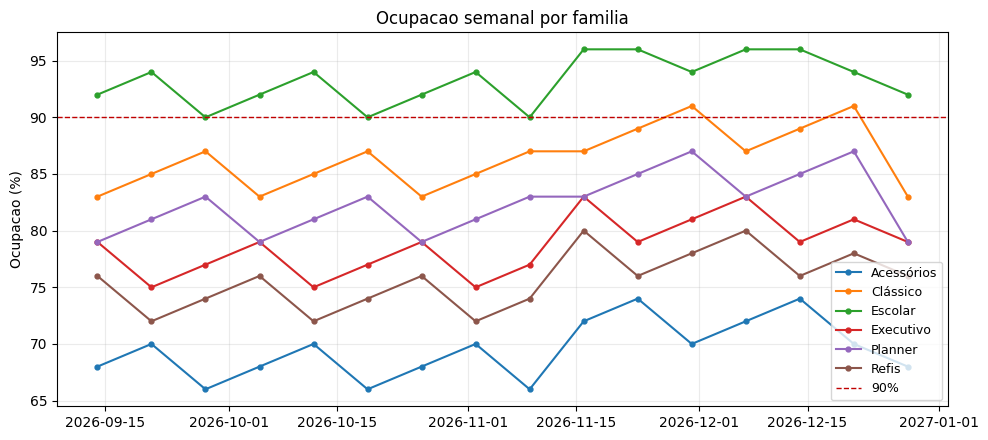

In [ ]:
fig, ax = plt.subplots()
for fam, g in capacidade.groupby("Família"):
    g = g.sort_values("Semana inicial")
    ax.plot(pd.to_datetime(g["Semana inicial"]), g["Ocupação"]*100, marker="o", ms=3.5, label=fam)
ax.axhline(90, color="#C00000", ls="--", lw=1, label="90%")
ax.set_ylabel("Ocupacao (%)"); ax.set_title("Ocupacao semanal por familia"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 6. Visibilidade B2B2C

A matriz possível usa apenas os parceiros B2B da aba `Parceiros_Canais`, excluindo os canais
diretos, que por definição têm sell-out completo. A escolha do denominador é o que faz a cobertura
ser 20% e não outro número, então ela fica explícita na evidência.

In [ ]:
print(parceiros[["Código", "Nome fictício", "Tipo", "Cobertura de sell-out", "SKUs com sell-out"]].to_string(index=False))

parc_b2b = parceiros[parceiros["Tipo"] != "Canal direto"]
n_par, n_sku = parc_b2b["Código"].nunique(), produtos["SKU"].nunique()
pares_possiveis = n_par * n_sku
pares_com_dado = sell_out.groupby(["Cliente", "SKU"]).ngroups

registrar("B2B-01", "B2B2C",
          "Cobertura de sell-out sobre a matriz parceiro B2B x SKU",
          "Sell_Out: Cliente, SKU | Parceiros_Canais: Código, Tipo | Produtos: SKU",
          f'pares distintos em Sell_Out / ({n_par} parceiros B2B x {n_sku} SKUs)',
          f"{pares_com_dado/pares_possiveis:.0%} ({pares_com_dado} de {pares_possiveis} pares), lacuna de {1-pares_com_dado/pares_possiveis:.0%}",
          suporte=(sell_out.groupby(["Cliente", "SKU"])
                   .agg(meses=("Mês", "nunique"), natureza=("Natureza do dado", "first"))
                   .reset_index()))

      Código       Nome fictício               Tipo Cobertura de sell-out  SKUs com sell-out
       KA-01 Papelaria Horizonte Parceiro varejista               Parcial                 10
       KA-02 Rede Ponto Criativo Parceiro varejista               Parcial                 10
       KA-03      Mundo do Papel       Distribuidor               Parcial                 10
       KA-04     Estação Escolar Parceiro varejista               Parcial                 10
       KA-05     Casa das Ideias       Distribuidor               Parcial                 10
  E-commerce  E-commerce próprio       Canal direto              Completo                 50
 Marketplace         Marketplace       Canal direto              Completo                 50
Loja própria        Loja própria       Canal direto              Completo                 50
B2B-01   [apurado]    Cobertura de sell-out sobre a matriz parceiro B2B x SKU
         valor ....... 20% (50 de 250 pares), lacuna de 80%
         origem ...... Se

In [ ]:
si = sell_in.groupby(["Cliente", "SKU"])["Quantidade enviada"].sum()
so = sell_out.groupby(["Cliente", "SKU"])["Quantidade vendida"].sum()
comp = pd.concat([si, so], axis=1).dropna()
comp["diferenca"] = comp["Quantidade enviada"] - comp["Quantidade vendida"]
comp["dif_pct"] = (comp["diferenca"] / comp["Quantidade enviada"] * 100).round(1)

registrar("B2B-02", "B2B2C",
          "Diferenca agregada entre sell-in e sell-out no recorte com dado",
          "Sell_In: Quantidade enviada | Sell_Out: Quantidade vendida",
          'soma(sell-in) - soma(sell-out) nos pares com as duas informacoes',
          f"{comp['diferenca'].sum():,.0f} un ({comp['diferenca'].sum()/comp['Quantidade enviada'].sum():.1%}) "
          f"sobre {comp['Quantidade enviada'].sum():,.0f} un de sell-in".replace(",", "."),
          suporte=comp.reset_index().sort_values("diferenca", ascending=False))

topo = comp["diferenca"].idxmax()
registrar("B2B-03", "B2B2C",
          "Maior divergencia individual entre sell-in e sell-out",
          "Sell_In | Sell_Out, agrupados por Cliente e SKU",
          'linha de maior diferenca na comparacao de B2B-02',
          f"{topo[0]} / {topo[1]}: {comp.loc[topo,'Quantidade enviada']:.0f} de sell-in contra "
          f"{comp.loc[topo,'Quantidade vendida']:.0f} de sell-out, diferenca de {comp['diferenca'].max():.0f} un",
          suporte=(sell_in[(sell_in.Cliente==topo[0]) & (sell_in.SKU==topo[1])]
                   .merge(sell_out[(sell_out.Cliente==topo[0]) & (sell_out.SKU==topo[1])],
                          on=["Mês", "Cliente", "SKU"], how="outer").sort_values("Mês")))

B2B-02   [apurado]    Diferenca agregada entre sell-in e sell-out no recorte com dado
         valor ....... 1.524 un (2.5%) sobre 59.906 un de sell-in
         origem ...... Sell_In: Quantidade enviada | Sell_Out: Quantidade vendida
         expressao ... soma(sell-in) - soma(sell-out) nos pares com as duas informacoes
         suporte ..... 50 linhas (use suporte('B2B-02'))

B2B-03   [apurado]    Maior divergencia individual entre sell-in e sell-out
         valor ....... KA-02 / CI-0009: 1856 de sell-in contra 1093 de sell-out, diferenca de 763 un
         origem ...... Sell_In | Sell_Out, agrupados por Cliente e SKU
         expressao ... linha de maior diferenca na comparacao de B2B-02
         suporte ..... 12 linhas (use suporte('B2B-03'))



In [ ]:
# O mes a mes do caso mais divergente: mostra se e acumulo ou apenas defasagem de timing
suporte("B2B-03")

,Mês,Cliente,SKU,Quantidade enviada,Quantidade vendida,Estoque estimado cliente,Natureza do dado
0,2025-09-01,KA-02,CI-0009,163,96,235,Observado pelo parceiro
1,2025-10-01,KA-02,CI-0009,187,110,312,Observado pelo parceiro
2,2025-11-01,KA-02,CI-0009,141,83,370,Observado pelo parceiro
3,2025-12-01,KA-02,CI-0009,153,90,433,Observado pelo parceiro
4,2026-01-01,KA-02,CI-0009,253,149,537,Observado pelo parceiro
5,2026-02-01,KA-02,CI-0009,141,83,595,Observado pelo parceiro
6,2026-03-01,KA-02,CI-0009,175,103,667,Observado pelo parceiro
7,2026-04-01,KA-02,CI-0009,107,63,711,Observado pelo parceiro
8,2026-05-01,KA-02,CI-0009,136,80,767,Observado pelo parceiro
9,2026-06-01,KA-02,CI-0009,141,83,825,Observado pelo parceiro


B2B-04   [apurado]    Dispersao da cobertura de estoque dentro dos parceiros, em dias de venda ao consumidor
         valor ....... de 11 a 355 dias, media por parceiro entre 57 e 97 dias
         origem ...... Sell_Out: Estoque estimado cliente, Quantidade vendida, Mês
         expressao ... Estoque estimado em 08/2026 / (venda media diaria dos 3 meses ate 08/2026)
         suporte ..... 50 linhas (use suporte('B2B-04'))

Cliente
KA-01    57.3
KA-02    96.6
KA-03    95.3
KA-04    57.9
KA-05    57.6


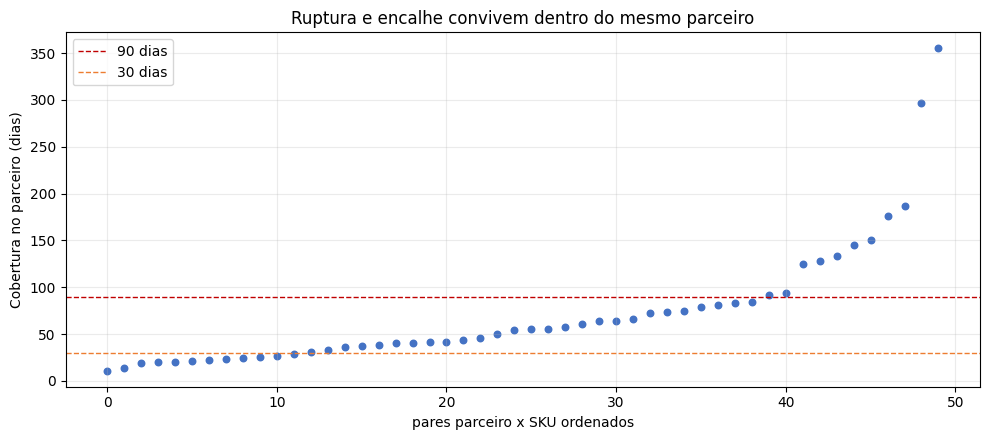

In [ ]:
ultimo = sell_out["Mês"].max()
venda_dia = (sell_out[sell_out["Mês"] >= ultimo - pd.DateOffset(months=2)]
             .groupby(["Cliente", "SKU"])["Quantidade vendida"].mean() / 30)
est_parc = sell_out[sell_out["Mês"] == ultimo].set_index(["Cliente", "SKU"])["Estoque estimado cliente"]
cob_canal = (est_parc / venda_dia).replace([np.inf, -np.inf], np.nan).dropna().rename("cobertura_dias")

registrar("B2B-04", "B2B2C",
          "Dispersao da cobertura de estoque dentro dos parceiros, em dias de venda ao consumidor",
          "Sell_Out: Estoque estimado cliente, Quantidade vendida, Mês",
          f'Estoque estimado em {ultimo:%m/%Y} / (venda media diaria dos 3 meses ate {ultimo:%m/%Y})',
          f"de {cob_canal.min():.0f} a {cob_canal.max():.0f} dias, media por parceiro entre "
          f"{cob_canal.groupby('Cliente').mean().min():.0f} e {cob_canal.groupby('Cliente').mean().max():.0f} dias",
          suporte=cob_canal.reset_index().sort_values("cobertura_dias"))

print(cob_canal.groupby("Cliente").mean().round(1).to_string())

fig, ax = plt.subplots()
ax.scatter(range(len(cob_canal)), cob_canal.sort_values(), s=22, color="#4472C4")
ax.axhline(90, color="#C00000", ls="--", lw=1, label="90 dias")
ax.axhline(30, color="#ED7D31", ls="--", lw=1, label="30 dias")
ax.set_xlabel("pares parceiro x SKU ordenados"); ax.set_ylabel("Cobertura no parceiro (dias)")
ax.set_title("Ruptura e encalhe convivem dentro do mesmo parceiro"); ax.legend()
plt.tight_layout(); plt.show()

## 7. Indicadores declarados pela empresa

Estes números vêm da aba `Indicadores_Atuais` e **não são recalculáveis** com os dados fornecidos:
não há histórico de entregas para recomputar o atendimento no prazo, nem realizado contra previsto
por mês para recomputar o MAPE. Entram na entrega como contexto declarado, nunca como apuração
nossa. A distinção é registrada no campo natureza.

In [ ]:
print(indicadores.to_string(index=False))
print()
for _, r in indicadores.iterrows():
    registrar(f"DEC-{_+1:02d}", "Declarado", r["Indicador"],
              "Indicadores_Atuais: Indicador, Valor fictício atual, Meta fictícia",
              "informado pela empresa, sem dado de base para recalcular",
              f"{r['Valor fictício atual']} (meta {r['Meta fictícia']})",
              natureza="declarado")

                     Indicador Valor fictício atual                  Meta fictícia Frequência   Responsável
   Rupturas mensais da amostra              14 SKUs                       ≤ 6 SKUs     Mensal PCP/Comercial
   SKUs com cobertura >90 dias                  18%                          ≤ 10%    Semanal           PCP
      Acurácia forecast (MAPE)                  31%                          ≤ 20%     Mensal          S&OP
   Aderência plano de produção                  78%                          ≥ 90%    Semanal           PCP
         Estoque médio amostra  R$ 1,8 mi fictícios Reduzir 10% sem elevar ruptura     Mensal        Supply
    Pedidos atendidos no prazo                  89%                          ≥ 96%    Semanal     Operações
   Tempo manual de análise PCP          22 h/semana                   ≤ 8 h/semana    Semanal           PCP
KAs com sell-in/out disponível                    5           Ampliar gradualmente     Mensal     Comercial

DEC-01   [declarado]  Ruptu

In [ ]:
# Unica excecao: a contagem de KAs com sell-in/out declarada e conferivel contra a base
declarado = int(str(indicadores.loc[indicadores.Indicador.str.contains("KAs"), "Valor fictício atual"].iloc[0]).strip())
apurado = sell_out["Cliente"].nunique()
print(f"Declarado: {declarado} KAs com sell-in/out | Apurado na aba Sell_Out: {apurado} | "
      f"{'confere' if declarado == apurado else 'DIVERGE'}")

Declarado: 5 KAs com sell-in/out | Apurado na aba Sell_Out: 5 | confere


## 8. Estratificação do portfólio

Cada SKU recebe uma classe nas quatro dimensões do recorte. A dimensão demanda usa comparação
**ano contra ano** (últimos 12 meses contra os 12 anteriores), e não semestral, para não confundir
sazonalidade de Volta às Aulas com tendência.

In [ ]:
def classe_estoque(r):
    if r["posicao_negativa"]: return "1. ruptura"
    if r["abaixo_seguranca"] or r["risco_lead_time"]: return "2. atencao"
    if r["excesso_90d"]: return "4. excesso/aging"
    return "3. adequado"

fim = vendas["Mês"].max()
ult12 = vendas[vendas["Mês"] > fim - pd.DateOffset(months=12)].groupby("SKU")["Quantidade faturada"].sum()
ant12 = vendas[vendas["Mês"] <= fim - pd.DateOffset(months=12)].groupby("SKU")["Quantidade faturada"].sum()
var_yoy = ((ult12 - ant12) / ant12).rename("var_yoy")
print(f"Janela: {fim - pd.DateOffset(months=11):%m/%Y} a {fim:%m/%Y} contra os 12 meses anteriores")

def classe_demanda(v):
    if pd.isna(v): return "sem historico"
    if v > .10: return "crescente"
    if v < -.10: return "decrescente"
    return "estavel"

dif_canal = comp.groupby("SKU")["diferenca"].sum()
si_sku = sell_in.groupby("SKU")["Quantidade enviada"].sum()
def classe_canal(sku):
    if sku not in dif_canal.index or si_sku.get(sku, 0) == 0: return "informacao insuficiente"
    r = dif_canal[sku] / si_sku[sku]
    return "sell-in > sell-out" if r > .05 else ("sell-out > sell-in" if r < -.05 else "aderente")

fam_saturadas = set(resumo_cap[resumo_cap["ocupacao_media"] > .90].index)
def classe_producao(r):
    if r["SKU"] in sem_op: return "carteira sem OP"
    if r["SKU"] in set(atrasados["SKU"]): return "OP apos a necessidade"
    if r["Família"] in fam_saturadas: return "restricao de capacidade"
    return "carteira coberta"

base_sku = base_sku.merge(var_yoy, on="SKU", how="left")
base_sku["dim_estoque"]  = base_sku.apply(classe_estoque, axis=1)
base_sku["dim_demanda"]  = base_sku["var_yoy"].apply(classe_demanda)
base_sku["dim_canal"]    = base_sku["SKU"].apply(classe_canal)
base_sku["dim_producao"] = base_sku.apply(classe_producao, axis=1)

for d in ["dim_estoque", "dim_demanda", "dim_canal", "dim_producao"]:
    registrar(f"DIM-{d[4:7].upper()}", "Estratificacao",
              f"Classificacao dos 50 SKUs na dimensao {d[4:]}",
              {"dim_estoque": "Produtos | Carteira_Pedidos | Ordens_Producao",
               "dim_demanda": "Vendas_24m: Mês, SKU, Quantidade faturada",
               "dim_canal": "Sell_In | Sell_Out por SKU",
               "dim_producao": "Carteira_Pedidos | Ordens_Producao | Capacidade_Semanal"}[d],
              {"dim_estoque": "regras de RUP-01 a RUP-03 e EXC-01, na ordem de severidade",
               "dim_demanda": "variacao dos ultimos 12 meses contra os 12 anteriores, corte de +/-10%",
               "dim_canal": "(sell-in - sell-out) / sell-in por SKU, corte de +/-5%",
               "dim_producao": "CAR-01, depois CAR-02, depois familia saturada"}[d],
              " | ".join(f"{k}: {v}" for k, v in base_sku[d].value_counts().sort_index().items()),
              suporte=base_sku[["SKU", "Produto", d]].sort_values(d))

Janela: 09/2025 a 08/2026 contra os 12 meses anteriores
DIM-EST  [apurado]    Classificacao dos 50 SKUs na dimensao estoque
         valor ....... 1. ruptura: 5 | 2. atencao: 15 | 3. adequado: 24 | 4. excesso/aging: 6
         origem ...... Produtos | Carteira_Pedidos | Ordens_Producao
         expressao ... regras de RUP-01 a RUP-03 e EXC-01, na ordem de severidade
         suporte ..... 50 linhas (use suporte('DIM-EST'))

DIM-DEM  [apurado]    Classificacao dos 50 SKUs na dimensao demanda
         valor ....... crescente: 5 | decrescente: 4 | estavel: 41
         origem ...... Vendas_24m: Mês, SKU, Quantidade faturada
         expressao ... variacao dos ultimos 12 meses contra os 12 anteriores, corte de +/-10%
         suporte ..... 50 linhas (use suporte('DIM-DEM'))

DIM-CAN  [apurado]    Classificacao dos 50 SKUs na dimensao canal
         valor ....... aderente: 26 | informacao insuficiente: 20 | sell-in > sell-out: 4
         origem ...... Sell_In | Sell_Out por SKU
         expr

In [ ]:
print(pd.crosstab(base_sku["dim_estoque"], base_sku["dim_producao"], margins=True, margins_name="total").to_string())

dim_producao      OP apos a necessidade  carteira coberta  carteira sem OP  restricao de capacidade  total
dim_estoque                                                                                               
1. ruptura                            1                 0                4                        0      5
2. atencao                           10                 5                0                        0     15
3. adequado                           8                11                4                        1     24
4. excesso/aging                      1                 1                4                        0      6
total                                20                17               12                        1     50


In [ ]:
prioridade = base_sku[
    base_sku["dim_estoque"].isin(["1. ruptura", "2. atencao"]) &
    base_sku["dim_producao"].isin(["carteira sem OP", "OP apos a necessidade", "restricao de capacidade"])
].sort_values(["posicao_projetada", "Cobertura (dias)"])

registrar("REC-01", "Recorte",
          "SKUs que concentram risco de estoque e falha de plano de producao ao mesmo tempo",
          "cruzamento de dim_estoque com dim_producao",
          'dim_estoque in (ruptura, atencao) e dim_producao in (sem OP, OP apos a necessidade, restricao)',
          f"{len(prioridade)} de {len(base_sku)} SKUs",
          suporte=prioridade[["SKU", "Produto", "Família", "Curva ABC", "Cobertura (dias)",
                              "Lead time (dias)", "carteira", "ordens", "posicao_projetada",
                              "dim_estoque", "dim_canal", "dim_producao"]])
suporte("REC-01")

REC-01   [apurado]    SKUs que concentram risco de estoque e falha de plano de producao ao mesmo tempo
         valor ....... 15 de 50 SKUs
         origem ...... cruzamento de dim_estoque com dim_producao
         expressao ... dim_estoque in (ruptura, atencao) e dim_producao in (sem OP, OP apos a necessidade, restricao)
         suporte ..... 15 linhas (use suporte('REC-01'))



,SKU,Produto,Família,Curva ABC,Cobertura (dias),Lead time (dias),carteira,ordens,posicao_projetada,dim_estoque,dim_canal,dim_producao
3,CI-0004,Planner Semanal,Planner,A,30,21,866.0,0.0,-563.0,1. ruptura,aderente,carteira sem OP
35,CI-0036,Caderno A5 Verde,Clássico,B,55,16,1219.0,0.0,-477.0,1. ruptura,informacao insuficiente,carteira sem OP
17,CI-0018,Refil Checklist,Refis,A,6,12,921.0,500.0,-371.0,1. ruptura,aderente,OP apos a necessidade
19,CI-0020,Capa Colorida A5,Acessórios,A,30,13,680.0,0.0,-326.0,1. ruptura,aderente,carteira sem OP
15,CI-0016,Caderno Escolar Rosa,Escolar,A,30,20,255.0,0.0,-105.0,1. ruptura,aderente,carteira sem OP
48,CI-0049,Divisória A5 5un,Acessórios,C,6,12,614.0,600.0,46.0,2. atencao,informacao insuficiente,OP apos a necessidade
40,CI-0041,Caderno Escolar Rosa,Escolar,C,6,21,1046.0,1200.0,286.0,2. atencao,informacao insuficiente,OP apos a necessidade
16,CI-0017,Planner Diário,Planner,A,6,22,352.0,600.0,288.0,2. atencao,aderente,OP apos a necessidade
46,CI-0047,Caderno Executivo Preto,Executivo,C,10,26,130.0,400.0,337.0,2. atencao,informacao insuficiente,OP apos a necessidade
32,CI-0033,Disco G Preto,Acessórios,B,6,14,729.0,1200.0,521.0,2. atencao,informacao insuficiente,OP apos a necessidade


## 9. Trilha de auditoria

A tabela abaixo é a prestação de contas da entrega: toda afirmação numérica do documento tem aqui
a sua origem, a sua expressão e a quantidade de linhas de base que a sustentam.

In [ ]:
t = trilha()
print(f"{len(t)} evidencias registradas | "
      f"{(t.natureza=='apurado').sum()} apuradas da base | {(t.natureza=='declarado').sum()} declaradas pela empresa")
t[["id", "bloco", "natureza", "criterio", "valor", "origem", "expressao", "linhas_suporte"]]

29 evidencias registradas | 21 apuradas da base | 8 declaradas pela empresa


,id,bloco,natureza,criterio,valor,origem,expressao,linhas_suporte
0,RUP-01,Ruptura,apurado,Cobertura de estoque inferior ao lead time de ...,15 de 50 SKUs,"Produtos: Cobertura (dias), Lead time (dias)","produtos[""Cobertura (dias)""] < produtos[""Lead ...",15
1,RUP-02,Ruptura,apurado,Cobertura inferior ao estoque de seguranca def...,13 de 50 SKUs,"Produtos: Cobertura (dias), Estoque segurança ...","produtos[""Cobertura (dias)""] < produtos[""Estoq...",13
2,RUP-03,Ruptura,apurado,Posicao projetada negativa: estoque atual mais...,5 de 50 SKUs,Produtos: Estoque atual | Ordens_Producao: Qua...,Estoque atual + soma(Ordens.Quantidade) - soma...,5
3,EXC-01,Excesso,apurado,Cobertura de estoque superior a 90 dias,"6 de 50 SKUs, cobertura maxima de 110 dias",Produtos: Cobertura (dias),"produtos[""Cobertura (dias)""] > 90",6
4,EXC-02,Excesso,apurado,"Capital imobilizado nos SKUs acima de 90 dias,...",R$ 760.183,Produtos: Estoque atual | Precos_Produtos: Pre...,soma(Estoque atual * Preço unitário) sobre os ...,6
5,EXC-03,Excesso,apurado,"SKUs em descontinuacao, com risco de obsolesce...",2 de 50 SKUs,Produtos: Status,"produtos[""Status""].str.contains(""Descontinu"")",2
6,CAR-01,Carteira,apurado,SKUs com pedido em carteira e nenhuma ordem de...,12 de 40 SKUs com carteira,Carteira_Pedidos: SKU | Ordens_Producao: SKU,set(Carteira.SKU) - set(Ordens.SKU),15
7,CAR-02,Carteira,apurado,SKUs cuja primeira ordem de producao conclui d...,20 SKUs. 26 pedidos. 10.517 unidades. atraso m...,"Carteira_Pedidos: SKU, Data prometida | Ordens...",min(Ordens.Conclusão prevista) por SKU > Carte...,26
8,CAR-03,Carteira,apurado,SKUs com carteira sem lastro produtivo no praz...,32 de 40 SKUs com carteira,Carteira_Pedidos | Ordens_Producao,CAR-01 uniao CAR-02,32
9,CAR-04,Carteira,apurado,Volume em carteira confirmada contra volume em...,22.269 un em carteira contra 30.500 un em ordens,Carteira_Pedidos: Quantidade | Ordens_Producao...,soma(Carteira.Quantidade) e soma(Ordens.Quanti...,0


In [ ]:
# Exportacao: trilha completa e as linhas de suporte de cada evidencia apurada
t.drop(columns=[c for c in t.columns if c.startswith("_")]).to_csv(
    "trilha_evidencias_semana1.csv", index=False, encoding="utf-8-sig")
base_sku.to_csv("skus_classificados_semana1.csv", index=False, encoding="utf-8-sig")

exportadas = 0
for id, e in EVIDENCIAS.items():
    if e["_suporte"] is not None:
        e["_suporte"].to_csv(f"suporte_{id}.csv", index=False, encoding="utf-8-sig")
        exportadas += 1
print(f"trilha_evidencias_semana1.csv, skus_classificados_semana1.csv e {exportadas} arquivos suporte_*.csv")

trilha_evidencias_semana1.csv, skus_classificados_semana1.csv e 20 arquivos suporte_*.csv


---

### Limitações declaradas

- **Sem custo nem margem por SKU.** O capital de EXC-02 está a preço de tabela, o que superestima o
  valor econômico e não permite calcular margem perdida por ruptura.
- **Sem data-alvo de disponibilidade por parceiro e sem tempo de distribuição.** A análise de timing
  por canal permanece qualitativa.
- **Sell-out cobre 20% da matriz.** Todo SKU ou parceiro fora dessa cobertura entra como
  `informacao insuficiente`, e nunca como venda zero.
- **Os indicadores DEC-01 a DEC-08 não foram recalculados.** São declarações da empresa e estão
  marcados como tal na trilha.
- **Os critérios de ruptura e aging são nossos.** Estão explícitos em cada evidência e precisam ser
  confirmados com a empresa antes de virarem indicador oficial.